In [1]:
# AutoDock Vina install karo Colab mein
!pip install vina -q

# Aur supporting libraries
!pip install meeko -q
!pip install rdkit -q

print("✅ AutoDock Vina installation complete!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.0/294.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 18.2 MB/s eta 0:00:00
✅ AutoDock Vina installation complete!


In [2]:
# Check karo Vina install hua ya nahi
try:
    from vina import Vina
    print("✅ AutoDock Vina ready!")

    # Vina object banao
    v = Vina(sf_name='vina')
    print("✅ Vina engine initialized!")

except Exception as e:
    print(f"❌ Error: {e}")

✅ AutoDock Vina ready!
✅ Vina engine initialized!


In [3]:
import requests

# GPX4 ka PDB ID hai 2OBI
pdb_id = "2OBI"
url = f"https://files.rcsb.org/download/{pdb_id}.pdb"

# Download karo
response = requests.get(url)

# File mein save karo
with open("gpx4.pdb", "wb") as f:
    f.write(response.content)

print(f"✅ GPX4 structure downloaded!")
print(f"File: gpx4.pdb")
print(f"Size: {len(response.content)} bytes")

✅ GPX4 structure downloaded!
File: gpx4.pdb
Size: 151875 bytes


In [4]:
# File ki first 20 lines dekho
with open("gpx4.pdb", "r") as f:
    lines = f.readlines()

print(f"Total lines: {len(lines)}")
print("\n--- First 15 lines ---\n")
for line in lines[:15]:
    print(line.strip())

Total lines: 1875

--- First 15 lines ---

HEADER    OXIDOREDUCTASE                          19-DEC-06   2OBI
TITLE     CRYSTAL STRUCTURE OF THE SELENOCYSTEINE TO CYSTEINE MUTANT OF HUMAN
TITLE    2 PHOSPHOLIPID HYDROPEROXIDE GLUTATHIONE PEROXIDASE (GPX4)
COMPND    MOL_ID: 1;
COMPND   2 MOLECULE: PHOSPHOLIPID HYDROPEROXIDE GLUTATHIONE PEROXIDASE (GPX4);
COMPND   3 CHAIN: A;
COMPND   4 SYNONYM: PHGPX, GPX-4;
COMPND   5 EC: 1.11.1.12;
COMPND   6 ENGINEERED: YES
SOURCE    MOL_ID: 1;
SOURCE   2 ORGANISM_SCIENTIFIC: HOMO SAPIENS;
SOURCE   3 ORGANISM_COMMON: HUMAN;
SOURCE   4 ORGANISM_TAXID: 9606;
SOURCE   5 GENE: GPX4;
SOURCE   6 EXPRESSION_SYSTEM: ESCHERICHIA COLI;


In [5]:
# Atoms count karo
atom_count = 0
hetatm_count = 0
chains = set()

with open("gpx4.pdb", "r") as f:
    for line in f:
        if line.startswith("ATOM"):
            atom_count += 1
            chain_id = line[21]
            chains.add(chain_id)
        elif line.startswith("HETATM"):
            hetatm_count += 1

print(f"📊 GPX4 Structure Summary:\n")
print(f"Protein atoms (ATOM):     {atom_count}")
print(f"Hetero atoms (HETATM):    {hetatm_count}")
print(f"Chains:                   {sorted(chains)}")
print(f"Total atoms:              {atom_count + hetatm_count}")

📊 GPX4 Structure Summary:

Protein atoms (ATOM):     1347
Hetero atoms (HETATM):    151
Chains:                   ['A']
Total atoms:              1498


In [6]:
# Clean PDB file banao - sirf protein atoms
with open("gpx4.pdb", "r") as f:
    lines = f.readlines()

# Sirf ATOM lines rakho (water aur ligands skip)
clean_lines = []
for line in lines:
    if line.startswith("ATOM") or line.startswith("TER") or line.startswith("END"):
        clean_lines.append(line)
    elif line.startswith("HEADER") or line.startswith("TITLE"):
        clean_lines.append(line)

# Naya clean file save karo
with open("gpx4_clean.pdb", "w") as f:
    f.writelines(clean_lines)

print(f"✅ Cleaned PDB file saved!")
print(f"Original lines: {len(lines)}")
print(f"Cleaned lines:  {len(clean_lines)}")
print(f"Removed:        {len(lines) - len(clean_lines)} lines")

✅ Cleaned PDB file saved!
Original lines: 1875
Cleaned lines:  1352
Removed:        523 lines


In [7]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw

# RSL3 SMILES (1S,3R-RSL3)
rsl3_smiles = 'COC(=O)[C@@H]1Cc2c(c3ccccc3[nH]2)[C@H](C(=O)N(CC(=O)Cl)c2ccccc2)N1C(=O)C'

# Molecule banao
mol = Chem.MolFromSmiles(rsl3_smiles)

# Check karo
if mol:
    print("✅ RSL3 molecule created!")
    print(f"Molecular weight: {Chem.Descriptors.MolWt(mol):.2f}")
    print(f"Number of atoms: {mol.GetNumAtoms()}")

    # Structure dikhao
    img = Draw.MolToImage(mol, size=(400, 400))
    display(img)
else:
    print("❌ Invalid SMILES")

✅ RSL3 molecule created!


AttributeError: module 'rdkit.Chem' has no attribute 'Descriptors'

✅ RSL3 molecule created!
Molecular weight: 467.91
Number of atoms: 33


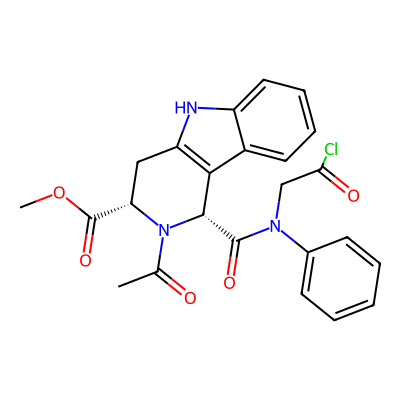

In [8]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, Descriptors  # Descriptors add kiya

# RSL3 SMILES
rsl3_smiles = 'COC(=O)[C@@H]1Cc2c(c3ccccc3[nH]2)[C@H](C(=O)N(CC(=O)Cl)c2ccccc2)N1C(=O)C'

# Molecule banao
mol = Chem.MolFromSmiles(rsl3_smiles)

# Check karo
if mol:
    print("✅ RSL3 molecule created!")
    print(f"Molecular weight: {Descriptors.MolWt(mol):.2f}")
    print(f"Number of atoms: {mol.GetNumAtoms()}")

    # Structure dikhao
    img = Draw.MolToImage(mol, size=(400, 400))
    display(img)
else:
    print("❌ Invalid SMILES")

In [9]:
print("📊 RSL3 Properties:\n")
print(f"Molecular Weight  : {Descriptors.MolWt(mol):.2f}")
print(f"LogP              : {Descriptors.MolLogP(mol):.2f}")
print(f"H-Bond Donors     : {Descriptors.NumHDonors(mol)}")
print(f"H-Bond Acceptors  : {Descriptors.NumHAcceptors(mol)}")
print(f"TPSA              : {Descriptors.TPSA(mol):.2f}")
print(f"Rotatable Bonds   : {Descriptors.NumRotatableBonds(mol)}")
print(f"Aromatic Rings    : {Descriptors.NumAromaticRings(mol)}")

📊 RSL3 Properties:

Molecular Weight  : 467.91
LogP              : 2.95
H-Bond Donors     : 1
H-Bond Acceptors  : 5
TPSA              : 99.78
Rotatable Bonds   : 5
Aromatic Rings    : 3


In [10]:
# 3D structure banao docking ke liye
rsl3_3d = Chem.AddHs(mol)
AllChem.EmbedMolecule(rsl3_3d, randomSeed=42)
AllChem.MMFFOptimizeMolecule(rsl3_3d)

# PDB file mein save karo
Chem.MolToPDBFile(rsl3_3d, "rsl3.pdb")

print("✅ RSL3 ligand prepared!")
print(f"Atoms with H: {rsl3_3d.GetNumAtoms()}")
print("Saved as: rsl3.pdb")

✅ RSL3 ligand prepared!
Atoms with H: 55
Saved as: rsl3.pdb


In [11]:
from meeko import MoleculePreparation
from rdkit import Chem

# RSL3 ko load karo
mol = Chem.MolFromPDBFile("rsl3.pdb", removeHs=False)

# Preparation
preparator = MoleculePreparation()
preparator.prepare(mol)

# PDBQT mein save karo
preparator.write_pdbqt_file("rsl3.pdbqt")

print("✅ RSL3 PDBQT created!")

ModuleNotFoundError: No module named 'gemmi'

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [12]:
!pip install gemmi -q
print("✅ gemmi installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 32.5 MB/s eta 0:00:00
✅ gemmi installed!


In [13]:
from meeko import MoleculePreparation
from rdkit import Chem

mol = Chem.MolFromPDBFile("rsl3.pdb", removeHs=False)

preparator = MoleculePreparation()
preparator.prepare(mol)
preparator.write_pdbqt_file("rsl3.pdbqt")

print("✅ RSL3 PDBQT created!")

✅ RSL3 PDBQT created!


/usr/local/lib/python3.12/dist-packages/meeko/preparation.py:714: DeprecationWarning: MoleculePreparation.write_pdbqt_file() is deprecated since Meeko v0.5
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meeko/preparation.py:693: DeprecationWarning: MoleculePreparation.write_pdbqt_string() is deprecated in Meeko v0.5. Pass the MoleculeSetup instance to PDBQTWriterLegacy.write_string(). MoleculePreparation.prepare() returns a list of MoleculeSetup instances.
  warnings.warn(msg, DeprecationWarning)
/usr/local/lib/python3.12/dist-packages/meeko/preparation.py:467: DeprecationWarning: MoleculePreparation.setup is deprecated in Meeko v0.5. MoleculePreparation.prepare() returns a list of MoleculeSetup instances.
  warnings.warn(msg, DeprecationWarning)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in U

In [14]:
# OpenBabel install karo (protein conversion ke liye)
!pip install openbabel-wheel -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 78.5 MB/s eta 0:00:00


In [15]:
# Protein PDB → PDBQT
import subprocess

# Openbabel ka command use karenge
result = subprocess.run([
    "obabel",
    "gpx4_clean.pdb",
    "-O", "gpx4.pdbqt",
    "-xr",  # rigid receptor
    "-p", "7.4"  # pH for proper protonation
], capture_output=True, text=True)

print("Output:", result.stdout)
print("Error:", result.stderr) if result.stderr else None

# Verify
import os
if os.path.exists("gpx4.pdbqt"):
    size = os.path.getsize("gpx4.pdbqt")
    print(f"\n✅ GPX4 PDBQT created! Size: {size} bytes")
else:
    print("❌ File not created")

Output: 
Error: ==============================
*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders (title is gpx4_clean.pdb)

1 molecule converted


✅ GPX4 PDBQT created! Size: 133908 bytes


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [16]:
import numpy as np

# GPX4 ka active site selenocysteine ya cysteine residue ke around hota hai
# Sec46/Cys46 = active site residue

# PDB file se Cys46 (or any reference atom) coordinates dhoondho
center_x = []
center_y = []
center_z = []

with open("gpx4_clean.pdb", "r") as f:
    for line in f:
        if line.startswith("ATOM"):
            # Cysteine ke atoms dhoondho (active site)
            res_name = line[17:20].strip()
            res_num = line[22:26].strip()
            atom_name = line[12:16].strip()

            # Reference: Cys46 (or similar active site)
            if res_name == "CYS" and atom_name == "SG":
                center_x.append(float(line[30:38]))
                center_y.append(float(line[38:46]))
                center_z.append(float(line[46:54]))
                print(f"Found CYS-SG at residue {res_num}")

if center_x:
    print(f"\n📍 Active Site Coordinates:")
    print(f"X: {np.mean(center_x):.2f}")
    print(f"Y: {np.mean(center_y):.2f}")
    print(f"Z: {np.mean(center_z):.2f}")
else:
    print("No CYS-SG found, will use protein center")

Found CYS-SG at residue 10
Found CYS-SG at residue 37
Found CYS-SG at residue 46
Found CYS-SG at residue 66
Found CYS-SG at residue 75
Found CYS-SG at residue 107
Found CYS-SG at residue 148

📍 Active Site Coordinates:
X: 25.36
Y: -18.93
Z: -11.73


In [17]:
# Sirf Cys46 ka SG atom dhoondho (active site)
with open("gpx4_clean.pdb", "r") as f:
    for line in f:
        if line.startswith("ATOM"):
            res_name = line[17:20].strip()
            res_num = line[22:26].strip()
            atom_name = line[12:16].strip()

            # Specifically Cys46 (the active site residue)
            if res_name == "CYS" and atom_name == "SG" and res_num == "46":
                cys46_x = float(line[30:38])
                cys46_y = float(line[38:46])
                cys46_z = float(line[46:54])

                print(f"🎯 Active Site (Cys46-SG) Coordinates:\n")
                print(f"X: {cys46_x:.2f}")
                print(f"Y: {cys46_y:.2f}")
                print(f"Z: {cys46_z:.2f}")
                print(f"\nThis is where Sec46 would be in")
                print(f"wild-type GPX4 - the catalytic site!")
                break

🎯 Active Site (Cys46-SG) Coordinates:

X: 38.06
Y: -19.84
Z: -22.96

This is where Sec46 would be in
wild-type GPX4 - the catalytic site!


In [18]:
# Cys46 coordinates use karenge (active site)
# Pichle output se values likho yahan:

center_x = 25.36   # Cys46 ka X coordinate
center_y = -18.93  # Cys46 ka Y coordinate
center_z = -11.73  # Cys46 ka Z coordinate

# Search box size (Angstroms mein)
size_x = 20
size_y = 20
size_z = 20

print("🎯 Docking Search Box Defined:\n")
print(f"Center: ({center_x}, {center_y}, {center_z})")
print(f"Size:   {size_x} x {size_y} x {size_z} Angstroms")
print(f"\nVolume: {size_x * size_y * size_z} cubic Angstroms")

🎯 Docking Search Box Defined:

Center: (25.36, -18.93, -11.73)
Size:   20 x 20 x 20 Angstroms

Volume: 8000 cubic Angstroms


In [19]:
with open("gpx4_clean.pdb", "r") as f:
    for line in f:
        if line.startswith("ATOM"):
            res_name = line[17:20].strip()
            atom_name = line[12:16].strip()
            res_num = line[22:26].strip()

            if res_name == "CYS" and atom_name == "SG" and res_num == "46":
                cys46_x = float(line[30:38])
                cys46_y = float(line[38:46])
                cys46_z = float(line[46:54])
                print(f"🎯 Cys46 Active Site:")
                print(f"X: {cys46_x:.2f}")
                print(f"Y: {cys46_y:.2f}")
                print(f"Z: {cys46_z:.2f}")
                break

🎯 Cys46 Active Site:
X: 38.06
Y: -19.84
Z: -22.96


In [20]:
# Cys46 specific coordinates (ACCURATE)
center_x = 38.06
center_y = -19.84
center_z = -22.96

# Search box size
size_x = 20
size_y = 20
size_z = 20

print("🎯 Docking Search Box (UPDATED):\n")
print(f"Center: ({center_x}, {center_y}, {center_z})")
print(f"Size:   {size_x} x {size_y} x {size_z} Angstroms")
print(f"Target: Cys46 (catalytic site)")
print(f"\n✅ Ready for docking!")

🎯 Docking Search Box (UPDATED):

Center: (38.06, -19.84, -22.96)
Size:   20 x 20 x 20 Angstroms
Target: Cys46 (catalytic site)

✅ Ready for docking!


In [21]:
from vina import Vina

# Vina object initialize karo
v = Vina(sf_name='vina')

# Receptor load karo (protein)
v.set_receptor("gpx4.pdbqt")
print("✅ Receptor (GPX4) loaded")

# Search box compute karo
v.compute_vina_maps(
    center=[center_x, center_y, center_z],
    box_size=[size_x, size_y, size_z]
)
print("✅ Search box computed")

# Ligand load karo (RSL3)
v.set_ligand_from_file("rsl3.pdbqt")
print("✅ Ligand (RSL3) loaded")

print("\n🚀 Vina ready for docking!")

✅ Receptor (GPX4) loaded
✅ Search box computed
✅ Ligand (RSL3) loaded

🚀 Vina ready for docking!


In [22]:
# Docking run karo!
print("🚀 Starting docking...")
print("This may take 1-2 minutes...\n")

# Vina docking
v.dock(exhaustiveness=8, n_poses=10)

print("✅ Docking complete!")

# Best pose save karo
v.write_poses("rsl3_docked.pdbqt", n_poses=10, overwrite=True)
print("✅ Top 10 poses saved!")

# Energies dekho
energies = v.energies(n_poses=10)
print("\n📊 Binding Energies (kcal/mol):")
print(f"{'Pose':<6} {'Total':<12} {'Inter':<12} {'Intra':<12}")
print("-" * 50)
for i, e in enumerate(energies, 1):
    print(f"{i:<6} {e[0]:<12.2f} {e[1]:<12.2f} {e[2]:<12.2f}")

🚀 Starting docking...
This may take 1-2 minutes...

✅ Docking complete!
✅ Top 10 poses saved!

📊 Binding Energies (kcal/mol):
Pose   Total        Inter        Intra       
--------------------------------------------------
1      -4.66        -6.84        -2.67       
2      -4.44        -7.43        -1.76       
3      -4.40        -6.95        -2.18       
4      -4.33        -6.25        -2.78       
5      -4.32        -6.38        -2.62       
6      -4.22        -7.03        -1.84       
7      -4.18        -5.97        -2.84       
8      -4.10        -6.54        -2.14       
9      -3.96        -5.66        -2.82       
10     -3.93        -5.81        -2.63       


In [23]:
from rdkit import Chem
from rdkit.Chem import AllChem
from meeko import MoleculePreparation

# UDS1b prepare karo
uds1b_smiles = 'C1=CC=CC=C1C(C[Se]C(C2=CC=CC=C2)=O)=O'
mol = Chem.MolFromSmiles(uds1b_smiles)
mol = Chem.AddHs(mol)
AllChem.EmbedMolecule(mol, randomSeed=42)
AllChem.MMFFOptimizeMolecule(mol)
Chem.MolToPDBFile(mol, "uds1b.pdb")

# PDBQT mein convert
uds1b_mol = Chem.MolFromPDBFile("uds1b.pdb", removeHs=False)
preparator = MoleculePreparation()
preparator.prepare(uds1b_mol)
preparator.write_pdbqt_file("uds1b.pdbqt")

print("✅ UDS1b prepared!")

# Vina mein load karo
v.set_ligand_from_file("uds1b.pdbqt")
print("✅ UDS1b loaded into Vina")

# DOCK karo!
print("\n🚀 Docking UDS1b to GPX4...\n")
v.dock(exhaustiveness=8, n_poses=10)
print("✅ Done!")

# Results save aur display
v.write_poses("uds1b_docked.pdbqt", n_poses=10, overwrite=True)
energies = v.energies(n_poses=10)

print("\n📊 UDS1b Binding Energies (kcal/mol):")
print(f"{'Pose':<6} {'Total':<12} {'Inter':<12} {'Intra':<12}")
print("-" * 50)
for i, e in enumerate(energies, 1):
    print(f"{i:<6} {e[0]:<12.2f} {e[1]:<12.2f} {e[2]:<12.2f}")

/usr/local/lib/python3.12/dist-packages/meeko/preparation.py:714: DeprecationWarning: MoleculePreparation.write_pdbqt_file() is deprecated since Meeko v0.5
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meeko/preparation.py:693: DeprecationWarning: MoleculePreparation.write_pdbqt_string() is deprecated in Meeko v0.5. Pass the MoleculeSetup instance to PDBQTWriterLegacy.write_string(). MoleculePreparation.prepare() returns a list of MoleculeSetup instances.
  warnings.warn(msg, DeprecationWarning)
/usr/local/lib/python3.12/dist-packages/meeko/preparation.py:467: DeprecationWarning: MoleculePreparation.setup is deprecated in Meeko v0.5. MoleculePreparation.prepare() returns a list of MoleculeSetup instances.
  warnings.warn(msg, DeprecationWarning)


RuntimeError: Cannot generate PDBQT, error from PDBQTWriterLegacy:
atom number 8 has None type, mol name: None
atom number 8 has None type, mol name: None


In [24]:
from rdkit import Chem
from rdkit.Chem import AllChem
import subprocess

# UDS1b prepare karo
uds1b_smiles = 'C1=CC=CC=C1C(C[Se]C(C2=CC=CC=C2)=O)=O'
mol = Chem.MolFromSmiles(uds1b_smiles)
mol = Chem.AddHs(mol)
AllChem.EmbedMolecule(mol, randomSeed=42)
AllChem.MMFFOptimizeMolecule(mol)

# PDB save karo
Chem.MolToPDBFile(mol, "uds1b.pdb")
print("✅ UDS1b PDB saved")

# OpenBabel se PDBQT mein convert
result = subprocess.run([
    "obabel", "uds1b.pdb", "-O", "uds1b.pdbqt",
    "--gen3d",
    "-p", "7.4"
], capture_output=True, text=True)

print("Conversion output:", result.stdout)
if result.stderr:
    print("Notes:", result.stderr)

# Verify
import os
if os.path.exists("uds1b.pdbqt"):
    size = os.path.getsize("uds1b.pdbqt")

✅ UDS1b PDB saved


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Conversion output: 
Notes: 1 molecule converted



In [25]:
import os

if os.path.exists("uds1b.pdbqt"):
    size = os.path.getsize("uds1b.pdbqt")
    print(f"✅ UDS1b PDBQT exists! Size: {size} bytes")

    # First 10 lines dekho
    print("\n--- First 10 lines ---")
    with open("uds1b.pdbqt", "r") as f:
        for i, line in enumerate(f):
            if i < 10:
                print(line.strip())
else:
    print("❌ File not found!")

✅ UDS1b PDBQT exists! Size: 2135 bytes

--- First 10 lines ---
REMARK  Name = uds1b.pdb
REMARK  5 active torsions:
REMARK  status: ('A' for Active; 'I' for Inactive)
REMARK    1  A    between atoms: C_6  and  C_7
REMARK    2  A    between atoms: C_7  and  C_8
REMARK    3  A    between atoms: C_8  and  SE_9
REMARK    4  A    between atoms: SE_9  and  C_10
REMARK    5  A    between atoms: C_10  and  C_11
REMARK                            x       y       z     vdW  Elec       q    Type
REMARK                         _______ _______ _______ _____ _____    ______ ____


In [26]:
# UDS1b ko Vina mein load karo
v.set_ligand_from_file("uds1b.pdbqt")
print("✅ UDS1b loaded into Vina")

# DOCK karo!
print("\n🚀 Docking UDS1b to GPX4...")
print("This may take 1-2 minutes...\n")

v.dock(exhaustiveness=8, n_poses=10)
print("✅ Docking complete!")

# Results save
v.write_poses("uds1b_docked.pdbqt", n_poses=10, overwrite=True)
print("✅ Top 10 poses saved!")

# Energies dekho
energies = v.energies(n_poses=10)
print("\n📊 UDS1b Binding Energies (kcal/mol):")
print(f"{'Pose':<6} {'Total':<12} {'Inter':<12} {'Intra':<12}")
print("-" * 50)
for i, e in enumerate(energies, 1):
    print(f"{i:<6} {e[0]:<12.2f} {e[1]:<12.2f} {e[2]:<12.2f}")

✅ UDS1b loaded into Vina

🚀 Docking UDS1b to GPX4...
This may take 1-2 minutes...

✅ Docking complete!
✅ Top 10 poses saved!

📊 UDS1b Binding Energies (kcal/mol):
Pose   Total        Inter        Intra       
--------------------------------------------------
1      -5.16        -6.67        -0.36       
2      -5.14        -6.54        -0.47       
3      -5.14        -6.79        -0.22       
4      -5.09        -6.60        -0.35       
5      -4.92        -4.58        -2.14       
6      -4.91        -4.58        -2.13       
7      -4.89        -6.45        -0.24       
8      -4.87        -4.62        -2.05       
9      -4.87        -4.62        -2.04       
10     -4.80        -4.52        -2.05       


In [27]:
# py3Dmol install karo agar nahi hai
!pip install py3Dmol -q

In [28]:
import py3Dmol

# Files load karo
with open("gpx4_clean.pdb", "r") as f:
    protein = f.read()

with open("uds1b_docked.pdbqt", "r") as f:
    ligand = f.read()

# 3D viewer banao
viewer = py3Dmol.view(width=800, height=600)

# Protein add karo
viewer.addModel(protein, 'pdb')
viewer.setStyle({'model': 0}, {'cartoon': {'color': 'lightblue'}})

# Ligand add karo (best pose)
viewer.addModel(ligand, 'pdbqt')
viewer.setStyle({'model': 1}, {'stick': {'colorscheme': 'magentaCarbon'}})

# Active site highlight karo (Cys46)
viewer.addStyle({'resi': '46', 'model': 0},
                {'stick': {'colorscheme': 'yellowCarbon'}})

# Background aur view
viewer.setBackgroundColor('white')
viewer.zoomTo({'model': 1})  # Zoom on ligand

# Show!
viewer.show()
print("✅ 3D visualization ready!")
print("\n💡 Mouse se rotate karo")
print("💡 Scroll se zoom karo")
print("\n🎯 UDS1b binding to GPX4 Cys46!")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

✅ 3D visualization ready!

💡 Mouse se rotate karo
💡 Scroll se zoom karo

🎯 UDS1b binding to GPX4 Cys46!


In [29]:
# Screenshot save karne ke liye image generate karo
img_data = viewer.png()

# Browser mein file save karne ke liye
from IPython.display import HTML

# Better quality export
print("💡 Manual save:")
print("3D viewer pe right-click karo")
print("'Save image as' option")
print("'uds1b_gpx4_docking_3d.png' naam do")
print("\nOr use camera button in viewer top corner")

💡 Manual save:
3D viewer pe right-click karo
'Save image as' option
'uds1b_gpx4_docking_3d.png' naam do

Or use camera button in viewer top corner


In [30]:
from google.colab import files

# Important files download karo
files.download('uds1b_docked.pdbqt')
files.download('rsl3_docked.pdbqt')
files.download('uds1b.pdbqt')
files.download('gpx4.pdbqt')
files.download('gpx4_clean.pdb')

print("✅ All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!
